In [1]:
!pip -q install "transformers==4.41.2" "tokenizers==0.19.1" sentencepiece accelerate
!pip -q install evaluate rouge_score sacrebleu nltk tqdm scikit-learn

import os, gc, json, math, random, time
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, T5ForConditionalGeneration, get_linear_schedule_with_warmup

from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.set_float32_matmul_precision("high")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_BF16 = torch.cuda.is_available()

print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("BF16:", USE_BF16)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 105.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 122.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.9 MB/s eta 0:00:00
Device: cuda
GPU: NVIDIA A100-SXM4-80GB
BF16: True


In [2]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/Senior2_Medical_Captioning")
DATASET_DIR = PROJECT_DIR / "caption_generator_datasets_umls_terms"

EXP4_BEST_MODEL = PROJECT_DIR / "models" / "exp4_mixed_gt_pred_micro_terms_t5_base_safe5" / "best_model"

EXP5_DIR = PROJECT_DIR / "models" / "exp5_image_only_biomedclip_visual_prefix_t5"
EXP5_FEATURE_DIR = EXP5_DIR / "precomputed_features"
EXP5_BEST_MODEL = EXP5_DIR / "best_model"
EXP5_ADAPTER = EXP5_BEST_MODEL / "visual_prefix_adapter.pt"

EXP6_DIR = PROJECT_DIR / "models" / "exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5"
EXP6_PROCESSED_DIR = EXP6_DIR / "processed"
EXP6_DIR.mkdir(parents=True, exist_ok=True)
EXP6_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Exp5 feature files
TRAIN_FEATURES = EXP5_FEATURE_DIR / "train_biomedclip_features.npy"
VALID_FEATURES = EXP5_FEATURE_DIR / "valid3000_biomedclip_features.npy"

TRAIN_IDS = EXP5_FEATURE_DIR / "train_ids.csv"
VALID_IDS = EXP5_FEATURE_DIR / "valid3000_ids.csv"

# Exp5 metadata
TRAIN_META = EXP5_DIR / "exp5_train_metadata.csv"
VALID_META = EXP5_DIR / "exp5_valid3000_metadata.csv"

# Concept datasets
GT_TRAIN_CSV = DATASET_DIR / "gt_cui_terms_train.csv"
GT_VALID_CSV = DATASET_DIR / "gt_cui_terms_valid.csv"

PRED_MICRO_TRAIN_CSV = DATASET_DIR / "pred_micro_cui_terms_train.csv"
PRED_MICRO_VALID_CSV = DATASET_DIR / "pred_micro_cui_terms_valid.csv"

PRED_COVERAGE_VALID_CSV = DATASET_DIR / "pred_coverage_cui_terms_valid.csv"

paths_to_check = [
    PROJECT_DIR, DATASET_DIR,
    EXP4_BEST_MODEL,
    EXP5_FEATURE_DIR, EXP5_BEST_MODEL, EXP5_ADAPTER,
    TRAIN_FEATURES, VALID_FEATURES,
    TRAIN_IDS, VALID_IDS,
    TRAIN_META, VALID_META,
    GT_TRAIN_CSV, GT_VALID_CSV,
    PRED_MICRO_TRAIN_CSV, PRED_MICRO_VALID_CSV,
    PRED_COVERAGE_VALID_CSV
]

for p in paths_to_check:
    print(str(p), "->", p.exists())

missing = [str(p) for p in paths_to_check if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required files:\n" + "\n".join(missing))

Mounted at /content/drive
/content/drive/MyDrive/Senior2_Medical_Captioning -> True
/content/drive/MyDrive/Senior2_Medical_Captioning/caption_generator_datasets_umls_terms -> True
/content/drive/MyDrive/Senior2_Medical_Captioning/models/exp4_mixed_gt_pred_micro_terms_t5_base_safe5/best_model -> True
/content/drive/MyDrive/Senior2_Medical_Captioning/models/exp5_image_only_biomedclip_visual_prefix_t5/precomputed_features -> True
/content/drive/MyDrive/Senior2_Medical_Captioning/models/exp5_image_only_biomedclip_visual_prefix_t5/best_model -> True
/content/drive/MyDrive/Senior2_Medical_Captioning/models/exp5_image_only_biomedclip_visual_prefix_t5/best_model/visual_prefix_adapter.pt -> True
/content/drive/MyDrive/Senior2_Medical_Captioning/models/exp5_image_only_biomedclip_visual_prefix_t5/precomputed_features/train_biomedclip_features.npy -> True
/content/drive/MyDrive/Senior2_Medical_Captioning/models/exp5_image_only_biomedclip_visual_prefix_t5/precomputed_features/valid3000_biomedclip_f

In [3]:
train_meta = pd.read_csv(TRAIN_META)
valid_meta = pd.read_csv(VALID_META)

train_ids = pd.read_csv(TRAIN_IDS)
valid_ids = pd.read_csv(VALID_IDS)

print("Train meta:", train_meta.shape)
print("Valid meta:", valid_meta.shape)
print("Train IDs:", train_ids.shape)
print("Valid IDs:", valid_ids.shape)

# Verify feature order
assert train_meta["ID"].tolist() == train_ids["ID"].tolist(), "Train metadata and features ID order mismatch."
assert valid_meta["ID"].tolist() == valid_ids["ID"].tolist(), "Valid metadata and features ID order mismatch."

train_features_shape = np.load(TRAIN_FEATURES, mmap_mode="r").shape
valid_features_shape = np.load(VALID_FEATURES, mmap_mode="r").shape

print("Train features shape:", train_features_shape)
print("Valid features shape:", valid_features_shape)

IMAGE_FEATURE_DIM = train_features_shape[1]
print("IMAGE_FEATURE_DIM:", IMAGE_FEATURE_DIM)


def load_concept_map(path, name):
    df = pd.read_csv(path)
    required = {"ID", "input_text", "target_text"}
    missing_cols = required - set(df.columns)
    if missing_cols:
        raise ValueError(f"{name} missing columns: {missing_cols}")
    return df[["ID", "input_text", "target_text"]].copy()


gt_train = load_concept_map(GT_TRAIN_CSV, "gt_train")
pred_micro_train = load_concept_map(PRED_MICRO_TRAIN_CSV, "pred_micro_train")

gt_valid = load_concept_map(GT_VALID_CSV, "gt_valid")
pred_micro_valid = load_concept_map(PRED_MICRO_VALID_CSV, "pred_micro_valid")
pred_coverage_valid = load_concept_map(PRED_COVERAGE_VALID_CSV, "pred_coverage_valid")


# -----------------------------
# Train mixed dataframe
# -----------------------------
train_base = train_meta[["ID", "target_text"]].copy()

train_joined = (
    train_base
    .merge(gt_train[["ID", "input_text"]].rename(columns={"input_text": "gt_input_text"}), on="ID", how="left")
    .merge(pred_micro_train[["ID", "input_text"]].rename(columns={"input_text": "pred_micro_input_text"}), on="ID", how="left")
)

if train_joined["gt_input_text"].isna().any():
    raise ValueError("Missing GT input_text for some train IDs.")
if train_joined["pred_micro_input_text"].isna().any():
    raise ValueError("Missing Pred micro input_text for some train IDs.")

rng = np.random.default_rng(SEED)
use_gt = rng.random(len(train_joined)) < 0.50

train_mixed_df = train_joined[["ID", "target_text"]].copy()
train_mixed_df["input_text"] = np.where(
    use_gt,
    train_joined["gt_input_text"],
    train_joined["pred_micro_input_text"]
)
train_mixed_df["concept_source"] = np.where(use_gt, "GT concepts", "Pred micro concepts")

print("Train mixed shape:", train_mixed_df.shape)
print(train_mixed_df["concept_source"].value_counts())


# -----------------------------
# Valid dataframes, same order as valid features
# -----------------------------
valid_base = valid_meta[["ID", "target_text"]].copy()

def build_valid_setting(valid_base, concept_df, setting_name):
    out = valid_base.merge(
        concept_df[["ID", "input_text"]],
        on="ID",
        how="left"
    )
    if out["input_text"].isna().any():
        raise ValueError(f"Missing input_text for {setting_name}")
    out["setting"] = setting_name
    return out[["ID", "setting", "input_text", "target_text"]].copy()

valid_gt_df = build_valid_setting(valid_base, gt_valid, "Image + GT concepts")
valid_pred_micro_df = build_valid_setting(valid_base, pred_micro_valid, "Image + Pred micro concepts")
valid_pred_coverage_df = build_valid_setting(valid_base, pred_coverage_valid, "Image + Pred coverage concepts")

# Mixed validation for early stopping
valid_joined = (
    valid_base
    .merge(gt_valid[["ID", "input_text"]].rename(columns={"input_text": "gt_input_text"}), on="ID", how="left")
    .merge(pred_micro_valid[["ID", "input_text"]].rename(columns={"input_text": "pred_micro_input_text"}), on="ID", how="left")
)

use_gt_valid = rng.random(len(valid_joined)) < 0.50

valid_mixed_df = valid_joined[["ID", "target_text"]].copy()
valid_mixed_df["input_text"] = np.where(
    use_gt_valid,
    valid_joined["gt_input_text"],
    valid_joined["pred_micro_input_text"]
)
valid_mixed_df["setting"] = "Image + Mixed GT/Pred micro concepts"

print("\nValid settings:")
print("GT:", valid_gt_df.shape)
print("Pred micro:", valid_pred_micro_df.shape)
print("Pred coverage:", valid_pred_coverage_df.shape)
print("Valid mixed:", valid_mixed_df.shape)

display(train_mixed_df.head())
display(valid_gt_df.head())

Train meta: (97364, 4)
Valid meta: (3000, 4)
Train IDs: (97364, 1)
Valid IDs: (3000, 1)
Train features shape: (97364, 512)
Valid features shape: (3000, 512)
IMAGE_FEATURE_DIM: 512
Train mixed shape: (97364, 4)
concept_source
Pred micro concepts    48932
GT concepts            48432
Name: count, dtype: int64

Valid settings:
GT: (3000, 4)
Pred micro: (3000, 4)
Pred coverage: (3000, 4)
Valid mixed: (3000, 4)


,ID,target_text,input_text,concept_source
0,ImageCLEFmedical_Caption_2026_train_0,Head CT demonstrating left parotiditis.,generate medical caption from predicted micro-...,Pred micro concepts
1,ImageCLEFmedical_Caption_2026_train_1,Chest X-ray showing enlarged cardiac silhouett...,generate medical caption from ground-truth UML...,GT concepts
2,ImageCLEFmedical_Caption_2026_train_2,CT chest axial view showing a huge ascending a...,generate medical caption from predicted micro-...,Pred micro concepts
3,ImageCLEFmedical_Caption_2026_train_3,Acquired renal cysts in end-stage renal failur...,generate medical caption from predicted micro-...,Pred micro concepts
4,ImageCLEFmedical_Caption_2026_train_4,Computed tomography (CT) shows floating thromb...,generate medical caption from ground-truth UML...,GT concepts


,ID,setting,input_text,target_text
0,ImageCLEFmedical_Caption_2026_valid_12658,Image + GT concepts,generate medical caption from ground-truth UML...,Ultra-high-frequency ultrasound (48 MHz probe)...
1,ImageCLEFmedical_Caption_2026_valid_17336,Image + GT concepts,generate medical caption from ground-truth UML...,A midesophageal long axis view zoomed up on th...
2,ImageCLEFmedical_Caption_2026_valid_18790,Image + GT concepts,generate medical caption from ground-truth UML...,General aspect of the uterus and of the cervix...
3,ImageCLEFmedical_Caption_2026_valid_12815,Image + GT concepts,generate medical caption from ground-truth UML...,computed tomography of the chest with a white ...
4,ImageCLEFmedical_Caption_2026_valid_12666,Image + GT concepts,generate medical caption from ground-truth UML...,Lateral view of the skull showing multiple pun...


In [4]:
MAX_INPUT_LEN = 384
MAX_TARGET_LEN = 96

tokenizer = AutoTokenizer.from_pretrained(EXP4_BEST_MODEL)

def tokenize_inputs(df, name):
    input_ids_path = EXP6_PROCESSED_DIR / f"{name}_input_ids_max{MAX_INPUT_LEN}.npy"
    attn_path = EXP6_PROCESSED_DIR / f"{name}_attention_mask_max{MAX_INPUT_LEN}.npy"

    if input_ids_path.exists() and attn_path.exists():
        arr = np.load(input_ids_path, mmap_mode="r")
        if arr.shape[0] == len(df):
            print(f"[SKIP] Tokenized inputs exist for {name}: {arr.shape}")
            return input_ids_path, attn_path

    texts = df["input_text"].fillna("").astype(str).tolist()

    enc = tokenizer(
        texts,
        max_length=MAX_INPUT_LEN,
        padding="max_length",
        truncation=True,
        return_tensors="np"
    )

    input_ids = enc["input_ids"].astype(np.int32)
    attention_mask = enc["attention_mask"].astype(np.int8)

    np.save(input_ids_path, input_ids)
    np.save(attn_path, attention_mask)

    print(f"Saved tokenized inputs for {name}: {input_ids.shape}")
    return input_ids_path, attn_path


def tokenize_labels(df, name):
    labels_path = EXP6_PROCESSED_DIR / f"{name}_labels_max{MAX_TARGET_LEN}.npy"

    if labels_path.exists():
        arr = np.load(labels_path, mmap_mode="r")
        if arr.shape[0] == len(df):
            print(f"[SKIP] Labels exist for {name}: {arr.shape}")
            return labels_path

    texts = df["target_text"].fillna("").astype(str).tolist()

    enc = tokenizer(
        texts,
        max_length=MAX_TARGET_LEN,
        padding="max_length",
        truncation=True,
        return_tensors="np"
    )

    labels = enc["input_ids"].astype(np.int32)
    labels[labels == tokenizer.pad_token_id] = -100

    np.save(labels_path, labels)
    print(f"Saved labels for {name}: {labels.shape}")
    return labels_path


train_input_ids_path, train_attn_path = tokenize_inputs(train_mixed_df, "train_mixed")
valid_mixed_input_ids_path, valid_mixed_attn_path = tokenize_inputs(valid_mixed_df, "valid_mixed")

valid_gt_input_ids_path, valid_gt_attn_path = tokenize_inputs(valid_gt_df, "valid_gt")
valid_micro_input_ids_path, valid_micro_attn_path = tokenize_inputs(valid_pred_micro_df, "valid_pred_micro")
valid_coverage_input_ids_path, valid_coverage_attn_path = tokenize_inputs(valid_pred_coverage_df, "valid_pred_coverage")

train_labels_path = tokenize_labels(train_mixed_df, "train")
valid_labels_path = tokenize_labels(valid_mixed_df, "valid3000")

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Saved tokenized inputs for train_mixed: (97364, 384)
Saved tokenized inputs for valid_mixed: (3000, 384)
Saved tokenized inputs for valid_gt: (3000, 384)
Saved tokenized inputs for valid_pred_micro: (3000, 384)
Saved tokenized inputs for valid_pred_coverage: (3000, 384)
Saved labels for train: (97364, 96)
Saved labels for valid3000: (3000, 96)


In [5]:
class FusionCaptionDataset(Dataset):
    def __init__(self, df, feature_path, input_ids_path, attention_mask_path, labels_path=None):
        self.df = df.reset_index(drop=True)
        self.features = np.load(feature_path, mmap_mode="r")
        self.input_ids = np.load(input_ids_path, mmap_mode="r")
        self.attention_mask = np.load(attention_mask_path, mmap_mode="r")
        self.labels = np.load(labels_path, mmap_mode="r") if labels_path is not None else None

        assert len(self.df) == self.features.shape[0], "Feature length mismatch."
        assert len(self.df) == self.input_ids.shape[0], "Input IDs length mismatch."
        assert len(self.df) == self.attention_mask.shape[0], "Attention mask length mismatch."
        if self.labels is not None:
            assert len(self.df) == self.labels.shape[0], "Labels length mismatch."

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        item = {
            "image_features": torch.tensor(self.features[idx], dtype=torch.float32),
            "input_ids": torch.tensor(self.input_ids[idx], dtype=torch.long),
            "attention_mask": torch.tensor(self.attention_mask[idx], dtype=torch.long),
            "ID": self.df.iloc[idx]["ID"],
            "target_text": self.df.iloc[idx]["target_text"]
        }

        if "setting" in self.df.columns:
            item["setting"] = self.df.iloc[idx]["setting"]
        else:
            item["setting"] = self.df.iloc[idx].get("concept_source", "train")

        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)

        return item


def collate_fusion(batch):
    out = {
        "image_features": torch.stack([b["image_features"] for b in batch]),
        "input_ids": torch.stack([b["input_ids"] for b in batch]),
        "attention_mask": torch.stack([b["attention_mask"] for b in batch]),
        "ID": [b["ID"] for b in batch],
        "target_text": [b["target_text"] for b in batch],
        "setting": [b["setting"] for b in batch],
    }

    if "labels" in batch[0]:
        out["labels"] = torch.stack([b["labels"] for b in batch])

    return out


train_dataset = FusionCaptionDataset(
    train_mixed_df,
    TRAIN_FEATURES,
    train_input_ids_path,
    train_attn_path,
    train_labels_path
)

valid_mixed_dataset = FusionCaptionDataset(
    valid_mixed_df,
    VALID_FEATURES,
    valid_mixed_input_ids_path,
    valid_mixed_attn_path,
    valid_labels_path
)

valid_gt_dataset = FusionCaptionDataset(
    valid_gt_df,
    VALID_FEATURES,
    valid_gt_input_ids_path,
    valid_gt_attn_path,
    valid_labels_path
)

valid_micro_dataset = FusionCaptionDataset(
    valid_pred_micro_df,
    VALID_FEATURES,
    valid_micro_input_ids_path,
    valid_micro_attn_path,
    valid_labels_path
)

valid_coverage_dataset = FusionCaptionDataset(
    valid_pred_coverage_df,
    VALID_FEATURES,
    valid_coverage_input_ids_path,
    valid_coverage_attn_path,
    valid_labels_path
)

print("Train dataset:", len(train_dataset))
print("Valid mixed dataset:", len(valid_mixed_dataset))
print("Valid GT dataset:", len(valid_gt_dataset))
print("Valid pred micro dataset:", len(valid_micro_dataset))
print("Valid pred coverage dataset:", len(valid_coverage_dataset))

sample = train_dataset[0]
print("Sample image feature:", sample["image_features"].shape)
print("Sample input_ids:", sample["input_ids"].shape)
print("Sample labels:", sample["labels"].shape)
print("Source:", sample["setting"])

Train dataset: 97364
Valid mixed dataset: 3000
Valid GT dataset: 3000
Valid pred micro dataset: 3000
Valid pred coverage dataset: 3000
Sample image feature: torch.Size([512])
Sample input_ids: torch.Size([384])
Sample labels: torch.Size([96])
Source: Pred micro concepts


In [6]:
class ImageConceptFusionT5(nn.Module):
    def __init__(self, t5, image_feature_dim, prefix_len=16, dropout=0.1):
        super().__init__()

        self.t5 = t5
        self.prefix_len = prefix_len
        self.d_model = t5.config.d_model

        self.visual_projector = nn.Sequential(
            nn.LayerNorm(image_feature_dim),
            nn.Linear(image_feature_dim, self.d_model * prefix_len),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(self.d_model * prefix_len, self.d_model * prefix_len)
        )

    def build_visual_prefix(self, image_features):
        prefix = self.visual_projector(image_features)
        prefix = prefix.view(image_features.size(0), self.prefix_len, self.d_model)

        t5_dtype = next(self.t5.parameters()).dtype
        prefix = prefix.to(dtype=t5_dtype)

        prefix_attention = torch.ones(
            prefix.size(0),
            prefix.size(1),
            dtype=torch.long,
            device=prefix.device
        )

        return prefix, prefix_attention

    def build_fused_encoder_inputs(self, image_features, input_ids, attention_mask):
        visual_prefix, visual_attention = self.build_visual_prefix(image_features)

        text_embeds = self.t5.encoder.embed_tokens(input_ids)
        text_embeds = text_embeds.to(dtype=visual_prefix.dtype)

        fused_embeds = torch.cat([visual_prefix, text_embeds], dim=1)
        fused_attention = torch.cat([visual_attention, attention_mask], dim=1)

        return fused_embeds, fused_attention

    def forward(self, image_features, input_ids, attention_mask, labels=None):
        inputs_embeds, fused_attention = self.build_fused_encoder_inputs(
            image_features=image_features,
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        return self.t5(
            inputs_embeds=inputs_embeds,
            attention_mask=fused_attention,
            labels=labels
        )

    @torch.no_grad()
    def generate_from_fusion(self, image_features, input_ids, attention_mask, **generate_kwargs):
        inputs_embeds, fused_attention = self.build_fused_encoder_inputs(
            image_features=image_features,
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        return self.t5.generate(
            inputs_embeds=inputs_embeds,
            attention_mask=fused_attention,
            **generate_kwargs
        )


def build_fresh_exp6_model(load_exp5_adapter=True):
    print("Loading Exp4-initialized T5...")
    t5_model = T5ForConditionalGeneration.from_pretrained(EXP4_BEST_MODEL)
    t5_model.config.use_cache = False

    # Important for gradient checkpointing with embeddings
    t5_model.gradient_checkpointing_enable()
    if hasattr(t5_model, "enable_input_require_grads"):
        t5_model.enable_input_require_grads()

    model = ImageConceptFusionT5(
        t5=t5_model,
        image_feature_dim=IMAGE_FEATURE_DIM,
        prefix_len=16,
        dropout=0.1
    )

    if load_exp5_adapter:
        print("Loading Exp5 visual prefix adapter...")
        adapter_state = torch.load(EXP5_ADAPTER, map_location="cpu")
        model.visual_projector.load_state_dict(adapter_state["visual_projector_state_dict"], strict=True)
        print("Exp5 visual adapter loaded.")

    model = model.to(DEVICE)

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print("Model ready.")
    print("Total params:", f"{total_params:,}")
    print("Trainable params:", f"{trainable_params:,}")

    return model


model = build_fresh_exp6_model(load_exp5_adapter=True)

Loading Exp4-initialized T5...
Loading Exp5 visual prefix adapter...
Exp5 visual adapter loaded.
Model ready.
Total params: 382,226,944
Trainable params: 382,226,944


In [7]:
SANITY_BATCH_SIZE = 4

sanity_loader = DataLoader(
    valid_mixed_dataset,
    batch_size=SANITY_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=collate_fusion
)

model.eval()

batch = next(iter(sanity_loader))

image_features = batch["image_features"].to(DEVICE, non_blocking=True)
input_ids = batch["input_ids"].to(DEVICE, non_blocking=True)
attention_mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
labels = batch["labels"].to(DEVICE, non_blocking=True)

with torch.no_grad():
    with torch.autocast(device_type="cuda", dtype=torch.bfloat16, enabled=USE_BF16):
        outputs = model(
            image_features=image_features,
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss

print("Sanity loss:", float(loss.detach().cpu()))

generated_ids = model.generate_from_fusion(
    image_features=image_features,
    input_ids=input_ids,
    attention_mask=attention_mask,
    max_length=96,
    num_beams=2,
    early_stopping=True
)

preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)

for i in range(min(3, len(preds))):
    print("\nID:", batch["ID"][i])
    print("Target:", batch["target_text"][i][:300])
    print("Generated:", preds[i])

Sanity loss: 2.5910773277282715

ID: ImageCLEFmedical_Caption_2026_valid_12658
Target: Ultra-high-frequency ultrasound (48 MHz probe) accurately reveals lymphatic vessels and neighboring veins. The green arrow indicates the lymphatic collector; the blue arrow shows the vein.
Generated: Ultrasound image of a sagittal view of the sagittal view of the sagittal view of the sagittal view of the sagittal view of the sagittal view of the sagittal view of the sagittal view of the sagittal view.

ID: ImageCLEFmedical_Caption_2026_valid_17336
Target: A midesophageal long axis view zoomed up on the aortic valve demonstrating the Impella traversing an open aortic valve. (A) Impella. (B) Ascending aortic root.
Generated: Transthoracic echocardiogram showing a large obstructive mass in the left atrium (arrow).

ID: ImageCLEFmedical_Caption_2026_valid_18790
Target: General aspect of the uterus and of the cervix during an intravaginal ultrasound.
Generated: Ultrasound image of the uterus showing a lar

In [8]:
# Training settings
BATCH_SIZE = 16
GRAD_ACCUM = 2
MAX_EPOCHS = 5

ADAPTER_LR = 8e-5
T5_LR = 1e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.06
MAX_GRAD_NORM = 1.0

EARLY_STOPPING_PATIENCE = 2
MIN_DELTA = 0.003

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=collate_fusion
)

valid_loader = DataLoader(
    valid_mixed_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=collate_fusion
)

optimizer = AdamW(
    [
        {"params": model.visual_projector.parameters(), "lr": ADAPTER_LR},
        {"params": model.t5.parameters(), "lr": T5_LR},
    ],
    weight_decay=WEIGHT_DECAY
)

steps_per_epoch = math.ceil(len(train_loader) / GRAD_ACCUM)
total_train_steps = steps_per_epoch * MAX_EPOCHS
warmup_steps = int(total_train_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_train_steps
)

print("Train loader batches:", len(train_loader))
print("Steps per epoch:", steps_per_epoch)
print("Total optimizer steps:", total_train_steps)
print("Warmup steps:", warmup_steps)


@torch.no_grad()
def evaluate_loss(model, loader):
    model.eval()
    losses = []

    for batch in tqdm(loader, desc="Validation loss"):
        image_features = batch["image_features"].to(DEVICE, non_blocking=True)
        input_ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        attention_mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
        labels = batch["labels"].to(DEVICE, non_blocking=True)

        with torch.autocast(device_type="cuda", dtype=torch.bfloat16, enabled=USE_BF16):
            outputs = model(
                image_features=image_features,
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss

        losses.append(float(loss.detach().cpu()))

    return float(np.mean(losses))


def save_exp6_model(model, save_dir, extra_config=None):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    model.t5.save_pretrained(save_dir / "t5")
    tokenizer.save_pretrained(save_dir / "t5")

    torch.save(
        {
            "visual_projector_state_dict": model.visual_projector.state_dict(),
            "image_feature_dim": IMAGE_FEATURE_DIM,
            "prefix_len": model.prefix_len,
            "base_t5": str(EXP4_BEST_MODEL),
            "initialized_visual_adapter_from": str(EXP5_ADAPTER),
        },
        save_dir / "visual_prefix_adapter.pt"
    )

    config = {
        "experiment": "Exp6 Image + UMLS Concepts Fusion",
        "architecture": "BiomedCLIP precomputed image features + visual prefix + concept text embeddings + T5",
        "t5_initialized_from": str(EXP4_BEST_MODEL),
        "visual_adapter_initialized_from": str(EXP5_ADAPTER),
        "train_strategy": "Mixed 50% GT concepts + 50% Pred micro concepts, image always included",
        "image_feature_dim": IMAGE_FEATURE_DIM,
        "prefix_len": model.prefix_len,
        "max_input_len": MAX_INPUT_LEN,
        "max_target_len": MAX_TARGET_LEN,
        "batch_size": BATCH_SIZE,
        "grad_accum": GRAD_ACCUM,
        "effective_batch_size": BATCH_SIZE * GRAD_ACCUM,
        "max_epochs": MAX_EPOCHS,
        "adapter_lr": ADAPTER_LR,
        "t5_lr": T5_LR,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "min_delta": MIN_DELTA,
        "seed": SEED,
    }

    if extra_config:
        config.update(extra_config)

    with open(save_dir / "exp6_config.json", "w") as f:
        json.dump(config, f, indent=2)

    print("Saved model to:", save_dir)


BEST_DIR = EXP6_DIR / "best_model"
LAST_DIR = EXP6_DIR / "last_model"

history = []
best_val_loss = float("inf")
bad_epochs = 0
global_step = 0

start_time = time.time()

print("Starting Exp6 full training...")

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    running_losses = []

    optimizer.zero_grad(set_to_none=True)

    progress = tqdm(train_loader, desc=f"Epoch {epoch}/{MAX_EPOCHS}")

    for step, batch in enumerate(progress, start=1):
        image_features = batch["image_features"].to(DEVICE, non_blocking=True)
        input_ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        attention_mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
        labels = batch["labels"].to(DEVICE, non_blocking=True)

        with torch.autocast(device_type="cuda", dtype=torch.bfloat16, enabled=USE_BF16):
            outputs = model(
                image_features=image_features,
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss / GRAD_ACCUM

        if torch.isnan(loss):
            raise ValueError(f"NaN loss detected at epoch={epoch}, step={step}")

        loss.backward()

        if step % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)
            global_step += 1

        running_losses.append(float(loss.detach().cpu()) * GRAD_ACCUM)

        progress.set_postfix({
            "loss": f"{np.mean(running_losses[-50:]):.4f}",
            "lr_t5": f"{optimizer.param_groups[1]['lr']:.2e}",
            "lr_adapter": f"{optimizer.param_groups[0]['lr']:.2e}"
        })

    train_loss = float(np.mean(running_losses))
    val_loss = evaluate_loss(model, valid_loader)

    row = {
        "epoch": epoch,
        "global_step": global_step,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "elapsed_minutes": round((time.time() - start_time) / 60, 2)
    }

    history.append(row)
    pd.DataFrame(history).to_csv(EXP6_DIR / "training_history.csv", index=False)

    print("\nEpoch summary:", row)

    save_exp6_model(
        model,
        LAST_DIR,
        extra_config={"last_epoch": epoch, "last_val_loss": val_loss}
    )

    if val_loss < best_val_loss - MIN_DELTA:
        best_val_loss = val_loss
        bad_epochs = 0

        print("New best val_loss:", best_val_loss)

        save_exp6_model(
            model,
            BEST_DIR,
            extra_config={"best_epoch": epoch, "best_val_loss": best_val_loss}
        )
    else:
        bad_epochs += 1
        print(f"No significant improvement. bad_epochs={bad_epochs}/{EARLY_STOPPING_PATIENCE}")

        if bad_epochs >= EARLY_STOPPING_PATIENCE:
            print("Early stopping triggered.")
            break

print("\nTraining finished.")
print("Best val_loss:", best_val_loss)
print("Total time minutes:", round((time.time() - start_time) / 60, 2))

Train loader batches: 6086
Steps per epoch: 3043
Total optimizer steps: 15215
Warmup steps: 912
Starting Exp6 full training...


Epoch 1/5:   0%|          | 0/6086 [00:00<?, ?it/s]

Validation loss:   0%|          | 0/188 [00:00<?, ?it/s]


Epoch summary: {'epoch': 1, 'global_step': 3043, 'train_loss': 2.6204437834825556, 'val_loss': 2.4263175497663783, 'elapsed_minutes': 23.55}
Saved model to: /content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5/last_model
New best val_loss: 2.4263175497663783
Saved model to: /content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5/best_model


Epoch 2/5:   0%|          | 0/6086 [00:00<?, ?it/s]

...

Validation loss:   0%|          | 0/188 [00:00<?, ?it/s]


Epoch summary: {'epoch': 4, 'global_step': 12172, 'train_loss': 2.4840034061343195, 'val_loss': 2.3474409542185195, 'elapsed_minutes': 95.62}
Saved model to: /content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5/last_model
New best val_loss: 2.3474409542185195
Saved model to: /content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5/best_model


Epoch 5/5:   0%|          | 0/6086 [00:00<?, ?it/s]

Validation loss:   0%|          | 0/188 [00:00<?, ?it/s]


Epoch summary: {'epoch': 5, 'global_step': 15215, 'train_loss': 2.4694755941560853, 'val_loss': 2.3421410227075534, 'elapsed_minutes': 119.61}
Saved model to: /content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5/last_model
New best val_loss: 2.3421410227075534
Saved model to: /content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5/best_model

Training finished.
Best val_loss: 2.3421410227075534
Total time minutes: 120.18


In [9]:
gc.collect()
torch.cuda.empty_cache()

def load_exp6_saved_model(model_dir):
    model_dir = Path(model_dir)

    t5 = T5ForConditionalGeneration.from_pretrained(model_dir / "t5")
    t5.config.use_cache = False

    fusion_model = ImageConceptFusionT5(
        t5=t5,
        image_feature_dim=IMAGE_FEATURE_DIM,
        prefix_len=16,
        dropout=0.1
    )

    adapter_state = torch.load(model_dir / "visual_prefix_adapter.pt", map_location="cpu")
    fusion_model.visual_projector.load_state_dict(adapter_state["visual_projector_state_dict"], strict=True)

    fusion_model = fusion_model.to(DEVICE)
    fusion_model.eval()

    return fusion_model

print("Loading best Exp6 model from:")
print(BEST_DIR)

best_model = load_exp6_saved_model(BEST_DIR)
print("Best model loaded.")

Loading best Exp6 model from:
/content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5/best_model
Best model loaded.


In [10]:
import evaluate
import sacrebleu

GEN_BATCH_SIZE = 16
GEN_MAX_LEN = 96
GEN_NUM_BEAMS = 2

rouge_metric = evaluate.load("rouge")

def generate_predictions_for_setting(model, dataset, setting_name):
    loader = DataLoader(
        dataset,
        batch_size=GEN_BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
        collate_fn=collate_fusion
    )

    all_ids = []
    all_targets = []
    all_predictions = []
    all_settings = []

    model.eval()

    print(f"\nGenerating: {setting_name}")

    for batch in tqdm(loader, desc=f"Generating {setting_name}"):
        image_features = batch["image_features"].to(DEVICE, non_blocking=True)
        input_ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        attention_mask = batch["attention_mask"].to(DEVICE, non_blocking=True)

        generated_ids = model.generate_from_fusion(
            image_features=image_features,
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_length=GEN_MAX_LEN,
            num_beams=GEN_NUM_BEAMS,
            early_stopping=True
        )

        preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)

        all_ids.extend(batch["ID"])
        all_targets.extend(batch["target_text"])
        all_predictions.extend(preds)
        all_settings.extend([setting_name] * len(preds))

    pred_df = pd.DataFrame({
        "ID": all_ids,
        "experiment": "Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPrefix_Exp4T5",
        "setting": all_settings,
        "target_text": all_targets,
        "generated_text": all_predictions
    })

    rouge_scores = rouge_metric.compute(
        predictions=all_predictions,
        references=all_targets,
        use_stemmer=True
    )

    bleu_score = sacrebleu.corpus_bleu(
        all_predictions,
        [all_targets]
    ).score

    metrics = {
        "experiment": "Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPrefix_Exp4T5",
        "setting": setting_name,
        "n_samples": len(pred_df),
        "rouge1": float(rouge_scores["rouge1"]),
        "rouge2": float(rouge_scores["rouge2"]),
        "rougeL": float(rouge_scores["rougeL"]),
        "bleu": float(bleu_score),
        "best_val_loss": float(best_val_loss)
    }

    return pred_df, metrics


settings_to_eval = [
    ("Image + GT concepts", valid_gt_dataset),
    ("Image + Pred micro concepts", valid_micro_dataset),
    ("Image + Pred coverage concepts", valid_coverage_dataset),
]

all_pred_dfs = []
all_metrics = []

for setting_name, dataset in settings_to_eval:
    pred_df, metrics = generate_predictions_for_setting(best_model, dataset, setting_name)

    safe_name = setting_name.lower().replace(" + ", "_").replace(" ", "_").replace("/", "_")
    pred_path = EXP6_DIR / f"exp6_{safe_name}_valid3000_predictions.csv"
    pred_df.to_csv(pred_path, index=False)

    metrics["predictions_file"] = str(pred_path)

    all_pred_dfs.append(pred_df)
    all_metrics.append(metrics)

    print("\nMetrics for", setting_name)
    for k, v in metrics.items():
        print(k, ":", v)

combined_pred_df = pd.concat(all_pred_dfs, ignore_index=True)
combined_pred_path = EXP6_DIR / "exp6_all_settings_valid3000_predictions.csv"
combined_pred_df.to_csv(combined_pred_path, index=False)

metrics_df = pd.DataFrame(all_metrics)
metrics_path = EXP6_DIR / "exp6_all_settings_rouge_bleu_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

print("\nSaved combined predictions:")
print(combined_pred_path)

print("\nSaved metrics:")
print(metrics_path)

display(metrics_df)
display(combined_pred_df.head(10))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



Generating: Image + GT concepts


Generating Image + GT concepts:   0%|          | 0/188 [00:00<?, ?it/s]


Metrics for Image + GT concepts
experiment : Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPrefix_Exp4T5
setting : Image + GT concepts
n_samples : 3000
rouge1 : 0.365634666840922
rouge2 : 0.15818169386094666
rougeL : 0.32046782442238814
bleu : 6.692467280659776
best_val_loss : 2.3421410227075534
predictions_file : /content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5/exp6_image_gt_concepts_valid3000_predictions.csv

Generating: Image + Pred micro concepts


Generating Image + Pred micro concepts:   0%|          | 0/188 [00:00<?, ?it/s]


Metrics for Image + Pred micro concepts
experiment : Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPrefix_Exp4T5
setting : Image + Pred micro concepts
n_samples : 3000
rouge1 : 0.2503978357523803
rouge2 : 0.08674714104459706
rougeL : 0.21585596022318065
bleu : 3.5394165024856963
best_val_loss : 2.3421410227075534
predictions_file : /content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5/exp6_image_pred_micro_concepts_valid3000_predictions.csv

Generating: Image + Pred coverage concepts


Generating Image + Pred coverage concepts:   0%|          | 0/188 [00:00<?, ?it/s]


Metrics for Image + Pred coverage concepts
experiment : Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPrefix_Exp4T5
setting : Image + Pred coverage concepts
n_samples : 3000
rouge1 : 0.25125871544633305
rouge2 : 0.0870121746323502
rougeL : 0.2168476956523146
bleu : 3.4938370613635374
best_val_loss : 2.3421410227075534
predictions_file : /content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5/exp6_image_pred_coverage_concepts_valid3000_predictions.csv

Saved combined predictions:
/content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5/exp6_all_settings_valid3000_predictions.csv

Saved metrics:
/content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5/exp6_all_settings_rouge_bleu_metrics.csv


,experiment,setting,n_samples,rouge1,rouge2,rougeL,bleu,best_val_loss,predictions_file
0,Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPre...,Image + GT concepts,3000,0.365635,0.158182,0.320468,6.692467,2.342141,/content/drive/MyDrive/Senior2_Medical_Caption...
1,Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPre...,Image + Pred micro concepts,3000,0.250398,0.086747,0.215856,3.539417,2.342141,/content/drive/MyDrive/Senior2_Medical_Caption...
2,Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPre...,Image + Pred coverage concepts,3000,0.251259,0.087012,0.216848,3.493837,2.342141,/content/drive/MyDrive/Senior2_Medical_Caption...


,ID,experiment,setting,target_text,generated_text
0,ImageCLEFmedical_Caption_2026_valid_12658,Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPre...,Image + GT concepts,Ultra-high-frequency ultrasound (48 MHz probe)...,Ultrasound image of a sagittal view of a sagit...
1,ImageCLEFmedical_Caption_2026_valid_17336,Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPre...,Image + GT concepts,A midesophageal long axis view zoomed up on th...,Transesophageal echocardiogram showing the aor...
2,ImageCLEFmedical_Caption_2026_valid_18790,Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPre...,Image + GT concepts,General aspect of the uterus and of the cervix...,Ultrasound image of the uterus and cervix.
3,ImageCLEFmedical_Caption_2026_valid_12815,Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPre...,Image + GT concepts,computed tomography of the chest with a white ...,Chest computed tomography (CT) scan demonstrat...
4,ImageCLEFmedical_Caption_2026_valid_12666,Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPre...,Image + GT concepts,Lateral view of the skull showing multiple pun...,Lateral X-ray of the skull.
5,ImageCLEFmedical_Caption_2026_valid_11890,Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPre...,Image + GT concepts,Preoperative craniocaudal view of both shoulde...,Anteroposterior radiograph of the shoulder joi...
6,ImageCLEFmedical_Caption_2026_valid_3001,Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPre...,Image + GT concepts,CT Abdomen and Pelvis with contrast (Axial Vie...,Computed tomography scan of the pelvis showing...
7,ImageCLEFmedical_Caption_2026_valid_8202,Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPre...,Image + GT concepts,Chest CT-gross right pleural effusion (white a...,Chest computed tomography (CT) scan showing pl...
8,ImageCLEFmedical_Caption_2026_valid_14362,Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPre...,Image + GT concepts,The preoperative abdominopelvic contrast CT im...,Contrast-enhanced computed tomography (CT) of ...
9,ImageCLEFmedical_Caption_2026_valid_14768,Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPre...,Image + GT concepts,Angiography of the left vertebral artery. Trau...,Left vertebral artery angiography.


In [11]:
!pip -q install "bert-score==0.3.13" bleurt-pytorch

import os, re, json, math, time, gc
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.2 MB/s eta 0:00:00
Device: cuda
GPU: NVIDIA A100-SXM4-80GB


In [12]:
EXP6_DIR = Path("/content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5")
PROJECT_DIR = Path("/content/drive/MyDrive/Senior2_Medical_Captioning")

PRED_PATH = EXP6_DIR / "exp6_all_settings_valid3000_predictions.csv"
ROUGE_BLEU_PATH = EXP6_DIR / "exp6_all_settings_rouge_bleu_metrics.csv"
CUI_TERMS_PATH = PROJECT_DIR / "cui_to_umls_terms.csv"

ADD_METRICS_DIR = EXP6_DIR / "additional_metrics"
ADD_METRICS_DIR.mkdir(parents=True, exist_ok=True)

pred_df = pd.read_csv(PRED_PATH)
rouge_bleu_df = pd.read_csv(ROUGE_BLEU_PATH)

print("Predictions:", pred_df.shape)
print("ROUGE/BLEU:", rouge_bleu_df.shape)
print(pred_df["setting"].value_counts())

display(rouge_bleu_df)
display(pred_df.head())

Predictions: (9000, 5)
ROUGE/BLEU: (3, 9)
setting
Image + GT concepts               3000
Image + Pred micro concepts       3000
Image + Pred coverage concepts    3000
Name: count, dtype: int64


,experiment,setting,n_samples,rouge1,rouge2,rougeL,bleu,best_val_loss,predictions_file
0,Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPre...,Image + GT concepts,3000,0.365635,0.158182,0.320468,6.692467,2.342141,/content/drive/MyDrive/Senior2_Medical_Caption...
1,Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPre...,Image + Pred micro concepts,3000,0.250398,0.086747,0.215856,3.539417,2.342141,/content/drive/MyDrive/Senior2_Medical_Caption...
2,Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPre...,Image + Pred coverage concepts,3000,0.251259,0.087012,0.216848,3.493837,2.342141,/content/drive/MyDrive/Senior2_Medical_Caption...


,ID,experiment,setting,target_text,generated_text
0,ImageCLEFmedical_Caption_2026_valid_12658,Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPre...,Image + GT concepts,Ultra-high-frequency ultrasound (48 MHz probe)...,Ultrasound image of a sagittal view of a sagit...
1,ImageCLEFmedical_Caption_2026_valid_17336,Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPre...,Image + GT concepts,A midesophageal long axis view zoomed up on th...,Transesophageal echocardiogram showing the aor...
2,ImageCLEFmedical_Caption_2026_valid_18790,Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPre...,Image + GT concepts,General aspect of the uterus and of the cervix...,Ultrasound image of the uterus and cervix.
3,ImageCLEFmedical_Caption_2026_valid_12815,Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPre...,Image + GT concepts,computed tomography of the chest with a white ...,Chest computed tomography (CT) scan demonstrat...
4,ImageCLEFmedical_Caption_2026_valid_12666,Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPre...,Image + GT concepts,Lateral view of the skull showing multiple pun...,Lateral X-ray of the skull.


In [13]:
cui_df = pd.read_csv(CUI_TERMS_PATH)
print("CUI mapping columns:", cui_df.columns.tolist())
display(cui_df.head())

# Robust column detection
cols_lower = {c.lower(): c for c in cui_df.columns}

cui_col = None
for c in cui_df.columns:
    if c.lower() in ["cui", "cui_id", "umls_cui"]:
        cui_col = c
        break

term_col = None
for c in cui_df.columns:
    cl = c.lower()
    if "term" in cl or "name" in cl or "concept" in cl:
        if c != cui_col:
            term_col = c
            break

if cui_col is None:
    raise ValueError("Could not detect CUI column.")
if term_col is None:
    raise ValueError("Could not detect UMLS term/name column.")

print("Using CUI column:", cui_col)
print("Using term column:", term_col)


def normalize_text_for_umls(text):
    text = str(text).lower()
    text = text.replace("-", " ")
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def add_alias(alias_map, cui, alias):
    alias = normalize_text_for_umls(alias)
    if len(alias) >= 2:
        alias_map.setdefault(cui, set()).add(alias)


alias_map = {}

for _, row in cui_df.iterrows():
    cui = str(row[cui_col]).strip()
    term = str(row[term_col]).strip()

    if not cui or cui.lower() == "nan":
        continue
    if not term or term.lower() == "nan":
        continue

    norm_term = normalize_text_for_umls(term)
    add_alias(alias_map, cui, norm_term)

    # Helpful medical imaging aliases
    if "computed tomography" in norm_term or "x ray computed tomography" in norm_term:
        add_alias(alias_map, cui, "computed tomography")
        add_alias(alias_map, cui, "ct")
        add_alias(alias_map, cui, "ct scan")
        add_alias(alias_map, cui, "computed tomographic")

    if "magnetic resonance imaging" in norm_term:
        add_alias(alias_map, cui, "magnetic resonance imaging")
        add_alias(alias_map, cui, "mri")
        add_alias(alias_map, cui, "mr imaging")

    if "ultrasonography" in norm_term or "ultrasound" in norm_term:
        add_alias(alias_map, cui, "ultrasonography")
        add_alias(alias_map, cui, "ultrasound")
        add_alias(alias_map, cui, "sonography")
        add_alias(alias_map, cui, "us")

    if norm_term in ["x ray", "xray"] or "radiography" in norm_term:
        add_alias(alias_map, cui, "x ray")
        add_alias(alias_map, cui, "xray")
        add_alias(alias_map, cui, "x-ray")
        add_alias(alias_map, cui, "radiograph")
        add_alias(alias_map, cui, "radiography")

# Convert sets to sorted lists
alias_map = {cui: sorted(list(aliases), key=len, reverse=True) for cui, aliases in alias_map.items()}

print("Number of CUIs with aliases:", len(alias_map))
print("Total aliases:", sum(len(v) for v in alias_map.values()))


def extract_umls_concepts_fast(text, alias_map):
    norm = " " + normalize_text_for_umls(text) + " "
    found = set()

    for cui, aliases in alias_map.items():
        for alias in aliases:
            if " " + alias + " " in norm:
                found.add(cui)
                break

    return found


def concept_prf(ref_set, pred_set):
    if len(pred_set) == 0:
        precision = 0.0
    else:
        precision = len(ref_set & pred_set) / len(pred_set)

    if len(ref_set) == 0:
        recall = 0.0
    else:
        recall = len(ref_set & pred_set) / len(ref_set)

    if precision + recall == 0:
        f1 = 0.0
    else:
        f1 = 2 * precision * recall / (precision + recall)

    return precision, recall, f1


start = time.time()

umls_rows = []

for _, row in tqdm(pred_df.iterrows(), total=len(pred_df), desc="Dictionary UMLS F1"):
    ref_text = row["target_text"]
    gen_text = row["generated_text"]

    ref_set = extract_umls_concepts_fast(ref_text, alias_map)
    pred_set = extract_umls_concepts_fast(gen_text, alias_map)

    p, r, f1 = concept_prf(ref_set, pred_set)

    umls_rows.append({
        "ID": row["ID"],
        "setting": row["setting"],
        "ref_umls_count": len(ref_set),
        "pred_umls_count": len(pred_set),
        "matched_umls_count": len(ref_set & pred_set),
        "dict_umls_precision": p,
        "dict_umls_recall": r,
        "dict_umls_f1": f1,
        "ref_has_umls": int(len(ref_set) > 0),
        "pred_has_umls": int(len(pred_set) > 0),
    })

umls_df = pd.DataFrame(umls_rows)

print("Done in seconds:", round(time.time() - start, 2))
display(umls_df.head())

umls_summary = (
    umls_df
    .groupby("setting")
    .agg({
        "dict_umls_precision": "mean",
        "dict_umls_recall": "mean",
        "dict_umls_f1": "mean",
        "ref_has_umls": "mean",
        "pred_has_umls": "mean",
        "ref_umls_count": "mean",
        "pred_umls_count": "mean",
        "matched_umls_count": "mean",
    })
    .reset_index()
)

display(umls_summary)

CUI mapping columns: ['CUI', 'name', 'semantic_types', 'status_code', 'error']


,CUI,name,semantic_types,status_code,error
0,C0000726,Abdomen,Body Location or Region,200,NaN
1,C0000741,Abducens nerve structure,"Body Part, Organ, or Organ Component",200,NaN
2,C0000833,Abscess,Disease or Syndrome,200,NaN
3,C0000846,Agenesis,Congenital Abnormality,200,NaN
4,C0000962,Bone structure of acetabulum,"Body Part, Organ, or Organ Component",200,NaN


Using CUI column: CUI
Using term column: name
Number of CUIs with aliases: 2639
Total aliases: 2668


Dictionary UMLS F1:   0%|          | 0/9000 [00:00<?, ?it/s]

Done in seconds: 18.32


,ID,setting,ref_umls_count,pred_umls_count,matched_umls_count,dict_umls_precision,dict_umls_recall,dict_umls_f1,ref_has_umls,pred_has_umls
0,ImageCLEFmedical_Caption_2026_valid_12658,Image + GT concepts,2,1,1,1.000000,0.5,0.666667,1,1
1,ImageCLEFmedical_Caption_2026_valid_17336,Image + GT concepts,1,1,1,1.000000,1.0,1.000000,1,1
2,ImageCLEFmedical_Caption_2026_valid_18790,Image + GT concepts,2,2,2,1.000000,1.0,1.000000,1,1
3,ImageCLEFmedical_Caption_2026_valid_12815,Image + GT concepts,8,9,8,0.888889,1.0,0.941176,1,1
4,ImageCLEFmedical_Caption_2026_valid_12666,Image + GT concepts,0,0,0,0.000000,0.0,0.000000,0,0


,setting,dict_umls_precision,dict_umls_recall,dict_umls_f1,ref_has_umls,pred_has_umls,ref_umls_count,pred_umls_count,matched_umls_count
0,Image + GT concepts,0.584374,0.636556,0.585038,0.786,0.856333,3.413667,4.010333,2.868667
1,Image + Pred coverage concepts,0.446104,0.422935,0.412867,0.786,0.819000,3.413667,3.593000,2.208000
2,Image + Pred micro concepts,0.440627,0.420808,0.408807,0.786,0.814000,3.413667,3.569667,2.187333


In [14]:
from bert_score import BERTScorer

references = pred_df["target_text"].fillna("").astype(str).tolist()
candidates = pred_df["generated_text"].fillna("").astype(str).tolist()

print("Number of examples:", len(candidates))

start = time.time()

# Same setup used in previous experiments
bert_scorer = BERTScorer(
    model_type="microsoft/deberta-xlarge-mnli",
    lang="en",
    rescale_with_baseline=True,
    idf=True,
    idf_sents=references,
    device=DEVICE
)

P, R, F1 = bert_scorer.score(
    candidates,
    references,
    batch_size=16,
    verbose=True
)

bert_df = pd.DataFrame({
    "ID": pred_df["ID"].values,
    "setting": pred_df["setting"].values,
    "bertscore_precision": P.cpu().numpy(),
    "bertscore_recall": R.cpu().numpy(),
    "bertscore_f1": F1.cpu().numpy(),
})

print("BERTScore time minutes:", round((time.time() - start) / 60, 2))
display(bert_df.head())

bert_summary = (
    bert_df
    .groupby("setting")
    .agg({
        "bertscore_precision": "mean",
        "bertscore_recall": "mean",
        "bertscore_f1": "mean",
    })
    .reset_index()
)

display(bert_summary)

Number of examples: 9000


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/792 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

computing greedy matching.


  0%|          | 0/563 [00:00<?, ?it/s]

done in 60.97 seconds, 147.61 sentences/sec
BERTScore time minutes: 1.31


,ID,setting,bertscore_precision,bertscore_recall,bertscore_f1
0,ImageCLEFmedical_Caption_2026_valid_12658,Image + GT concepts,-0.325470,-0.247891,-0.283444
1,ImageCLEFmedical_Caption_2026_valid_17336,Image + GT concepts,0.382122,0.169084,0.270145
2,ImageCLEFmedical_Caption_2026_valid_18790,Image + GT concepts,0.709158,0.477989,0.587231
3,ImageCLEFmedical_Caption_2026_valid_12815,Image + GT concepts,0.468829,0.468396,0.470747
4,ImageCLEFmedical_Caption_2026_valid_12666,Image + GT concepts,0.560805,0.073549,0.277374


,setting,bertscore_precision,bertscore_recall,bertscore_f1
0,Image + GT concepts,0.419302,0.225548,0.310452
1,Image + Pred coverage concepts,0.252392,0.127965,0.180966
2,Image + Pred micro concepts,0.247863,0.128011,0.179153


In [15]:
from bleurt_pytorch import BleurtConfig, BleurtForSequenceClassification, BleurtTokenizer

BLEURT_MODEL_NAME = "lucadiliello/BLEURT-20"

print("Loading BLEURT model:", BLEURT_MODEL_NAME)

bleurt_tokenizer = BleurtTokenizer.from_pretrained(BLEURT_MODEL_NAME)
bleurt_model = BleurtForSequenceClassification.from_pretrained(BLEURT_MODEL_NAME)
bleurt_model = bleurt_model.to(DEVICE)
bleurt_model.eval()

def compute_bleurt_scores(references, candidates, batch_size=16, max_length=512):
    scores = []

    for i in tqdm(range(0, len(candidates), batch_size), desc="BLEURT"):
        batch_refs = references[i:i+batch_size]
        batch_cands = candidates[i:i+batch_size]

        inputs = bleurt_tokenizer(
            batch_refs,
            batch_cands,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = bleurt_model(**inputs)
            batch_scores = outputs.logits.squeeze(-1).detach().cpu().numpy()

        scores.extend(batch_scores.tolist())

    return np.array(scores, dtype=np.float32)

start = time.time()

bleurt_scores = compute_bleurt_scores(
    references=references,
    candidates=candidates,
    batch_size=16,
    max_length=512
)

bleurt_df = pd.DataFrame({
    "ID": pred_df["ID"].values,
    "setting": pred_df["setting"].values,
    "bleurt": bleurt_scores
})

print("BLEURT time minutes:", round((time.time() - start) / 60, 2))
display(bleurt_df.head())

bleurt_summary = (
    bleurt_df
    .groupby("setting")
    .agg({"bleurt": "mean"})
    .reset_index()
)

display(bleurt_summary)

Loading BLEURT model: lucadiliello/BLEURT-20


tokenizer_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'BleurtSPTokenizer'. 
The class this function is called from is 'BertTokenizer'.


spm.model:   0%|          | 0.00/4.70M [00:00<?, ?B/s]

...

BLEURT:   0%|          | 0/563 [00:00<?, ?it/s]

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

BLEURT time minutes: 0.43


,ID,setting,bleurt
0,ImageCLEFmedical_Caption_2026_valid_12658,Image + GT concepts,0.246932
1,ImageCLEFmedical_Caption_2026_valid_17336,Image + GT concepts,0.384448
2,ImageCLEFmedical_Caption_2026_valid_18790,Image + GT concepts,0.623061
3,ImageCLEFmedical_Caption_2026_valid_12815,Image + GT concepts,0.443426
4,ImageCLEFmedical_Caption_2026_valid_12666,Image + GT concepts,0.364487


,setting,bleurt
0,Image + GT concepts,0.419671
1,Image + Pred coverage concepts,0.346029
2,Image + Pred micro concepts,0.346307


In [16]:
# Per-sample merge
per_sample_metrics = pred_df.copy()

per_sample_metrics = per_sample_metrics.merge(
    bert_df,
    on=["ID", "setting"],
    how="left"
)

per_sample_metrics = per_sample_metrics.merge(
    bleurt_df,
    on=["ID", "setting"],
    how="left"
)

per_sample_metrics = per_sample_metrics.merge(
    umls_df,
    on=["ID", "setting"],
    how="left"
)

per_sample_path = ADD_METRICS_DIR / "exp6_all_settings_three_additional_metrics_per_sample.csv"
per_sample_metrics.to_csv(per_sample_path, index=False)

print("Saved per-sample additional metrics:")
print(per_sample_path)


# Summary merge
additional_summary = (
    per_sample_metrics
    .groupby("setting")
    .agg({
        "bertscore_precision": "mean",
        "bertscore_recall": "mean",
        "bertscore_f1": "mean",
        "bleurt": "mean",
        "dict_umls_precision": "mean",
        "dict_umls_recall": "mean",
        "dict_umls_f1": "mean",
        "ref_has_umls": "mean",
        "pred_has_umls": "mean",
        "ref_umls_count": "mean",
        "pred_umls_count": "mean",
        "matched_umls_count": "mean",
    })
    .reset_index()
)

additional_summary_path = ADD_METRICS_DIR / "exp6_all_settings_three_additional_metrics_summary.csv"
additional_summary.to_csv(additional_summary_path, index=False)

print("Saved additional metrics summary:")
print(additional_summary_path)

display(additional_summary)


# Merge ROUGE/BLEU with additional metrics
final_exp6_summary = rouge_bleu_df.merge(
    additional_summary,
    on="setting",
    how="left"
)

final_summary_path = ADD_METRICS_DIR / "exp6_final_all_metrics_summary_valid3000.csv"
final_exp6_summary.to_csv(final_summary_path, index=False)

print("Saved final Exp6 all metrics summary:")
print(final_summary_path)

display(final_exp6_summary)

Saved per-sample additional metrics:
/content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5/additional_metrics/exp6_all_settings_three_additional_metrics_per_sample.csv
Saved additional metrics summary:
/content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5/additional_metrics/exp6_all_settings_three_additional_metrics_summary.csv


,setting,bertscore_precision,bertscore_recall,bertscore_f1,bleurt,dict_umls_precision,dict_umls_recall,dict_umls_f1,ref_has_umls,pred_has_umls,ref_umls_count,pred_umls_count,matched_umls_count
0,Image + GT concepts,0.419302,0.225548,0.310452,0.419671,0.584374,0.636556,0.585038,0.786,0.856333,3.413667,4.010333,2.868667
1,Image + Pred coverage concepts,0.252392,0.127965,0.180966,0.346029,0.446104,0.422935,0.412867,0.786,0.819000,3.413667,3.593000,2.208000
2,Image + Pred micro concepts,0.247863,0.128011,0.179153,0.346307,0.440627,0.420808,0.408807,0.786,0.814000,3.413667,3.569667,2.187333


Saved final Exp6 all metrics summary:
/content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5/additional_metrics/exp6_final_all_metrics_summary_valid3000.csv


,experiment,setting,n_samples,rouge1,rouge2,rougeL,bleu,best_val_loss,predictions_file,bertscore_precision,...,bertscore_f1,bleurt,dict_umls_precision,dict_umls_recall,dict_umls_f1,ref_has_umls,pred_has_umls,ref_umls_count,pred_umls_count,matched_umls_count
0,Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPre...,Image + GT concepts,3000,0.365635,0.158182,0.320468,6.692467,2.342141,/content/drive/MyDrive/Senior2_Medical_Caption...,0.419302,...,0.310452,0.419671,0.584374,0.636556,0.585038,0.786,0.856333,3.413667,4.010333,2.868667
1,Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPre...,Image + Pred micro concepts,3000,0.250398,0.086747,0.215856,3.539417,2.342141,/content/drive/MyDrive/Senior2_Medical_Caption...,0.247863,...,0.179153,0.346307,0.440627,0.420808,0.408807,0.786,0.814000,3.413667,3.569667,2.187333
2,Exp6_Image_Concept_Fusion_BiomedCLIP_VisualPre...,Image + Pred coverage concepts,3000,0.251259,0.087012,0.216848,3.493837,2.342141,/content/drive/MyDrive/Senior2_Medical_Caption...,0.252392,...,0.180966,0.346029,0.446104,0.422935,0.412867,0.786,0.819000,3.413667,3.593000,2.208000


In [17]:
from bert_score import BERTScorer
import pandas as pd
import torch, time
from pathlib import Path

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

EXP6_DIR = Path("/content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5")
ADD_METRICS_DIR = EXP6_DIR / "additional_metrics"

PRED_PATH = EXP6_DIR / "exp6_all_settings_valid3000_predictions.csv"
ROUGE_BLEU_PATH = EXP6_DIR / "exp6_all_settings_rouge_bleu_metrics.csv"

pred_df = pd.read_csv(PRED_PATH)
rouge_bleu_df = pd.read_csv(ROUGE_BLEU_PATH)

references = pred_df["target_text"].fillna("").astype(str).tolist()
candidates = pred_df["generated_text"].fillna("").astype(str).tolist()

start = time.time()

bert_scorer = BERTScorer(
    model_type="microsoft/deberta-xlarge-mnli",
    lang="en",
    rescale_with_baseline=False,   # IMPORTANT: same scale as previous experiments
    idf=True,
    idf_sents=references,
    device=DEVICE
)

P, R, F1 = bert_scorer.score(
    candidates,
    references,
    batch_size=16,
    verbose=True
)

bert_df_corrected = pd.DataFrame({
    "ID": pred_df["ID"].values,
    "setting": pred_df["setting"].values,
    "bertscore_precision": P.cpu().numpy(),
    "bertscore_recall": R.cpu().numpy(),
    "bertscore_f1": F1.cpu().numpy(),
})

bert_corrected_path = ADD_METRICS_DIR / "exp6_bertscore_corrected_no_rescale_per_sample.csv"
bert_df_corrected.to_csv(bert_corrected_path, index=False)

bert_summary_corrected = (
    bert_df_corrected
    .groupby("setting")
    .agg({
        "bertscore_precision": "mean",
        "bertscore_recall": "mean",
        "bertscore_f1": "mean",
    })
    .reset_index()
)

bert_summary_corrected_path = ADD_METRICS_DIR / "exp6_bertscore_corrected_no_rescale_summary.csv"
bert_summary_corrected.to_csv(bert_summary_corrected_path, index=False)

print("BERTScore corrected time minutes:", round((time.time() - start) / 60, 2))
print("Saved corrected BERTScore:")
print(bert_summary_corrected_path)

display(bert_summary_corrected)

calculating scores...
computing bert embedding.


  0%|          | 0/588 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/563 [00:00<?, ?it/s]

done in 71.20 seconds, 126.40 sentences/sec
BERTScore corrected time minutes: 1.28
Saved corrected BERTScore:
/content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5/additional_metrics/exp6_bertscore_corrected_no_rescale_summary.csv


,setting,bertscore_precision,bertscore_recall,bertscore_f1
0,Image + GT concepts,0.719469,0.625962,0.665582
1,Image + Pred coverage concepts,0.638836,0.578832,0.602784
2,Image + Pred micro concepts,0.636648,0.578855,0.601905


,epoch,global_step,train_loss,val_loss,elapsed_minutes
0,1,3043,2.620444,2.426318,23.55
1,2,6086,2.549160,2.387695,47.51
2,3,9129,2.509412,2.363389,71.64
3,4,12172,2.484003,2.347441,95.62
4,5,15215,2.469476,2.342141,119.61


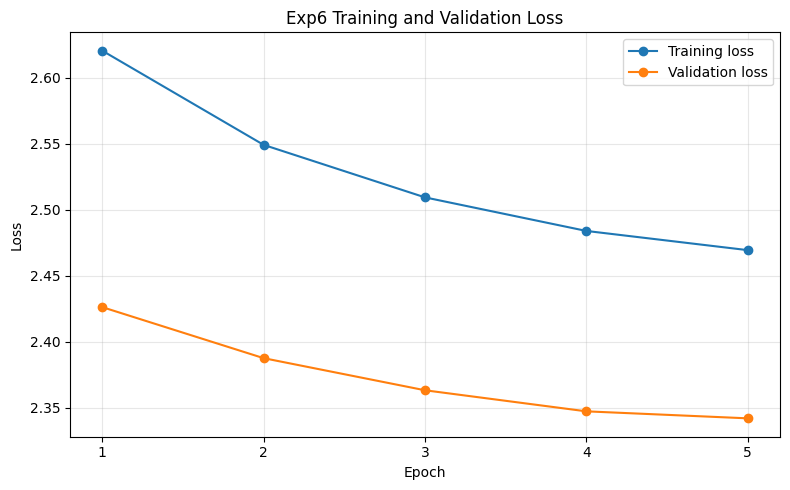

Saved: /content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5/figures/exp6_training_validation_loss.png


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/Senior2_Medical_Captioning")
EXP6_DIR = PROJECT_DIR / "models" / "exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5"

FIG_DIR = EXP6_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

history_path = EXP6_DIR / "training_history.csv"
history_df = pd.read_csv(history_path)

display(history_df)

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Training loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Exp6 Training and Validation Loss")
plt.xticks(history_df["epoch"])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

loss_fig_path = FIG_DIR / "exp6_training_validation_loss.png"
plt.savefig(loss_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", loss_fig_path)

,setting,rougeL,bleu,bertscore_f1,bleurt,dict_umls_f1
0,Image + GT concepts,0.320468,6.692467,0.665582,0.419671,0.585038
1,Image + Pred micro concepts,0.215856,3.539417,0.601905,0.346307,0.408807
2,Image + Pred coverage concepts,0.216848,3.493837,0.602784,0.346029,0.412867


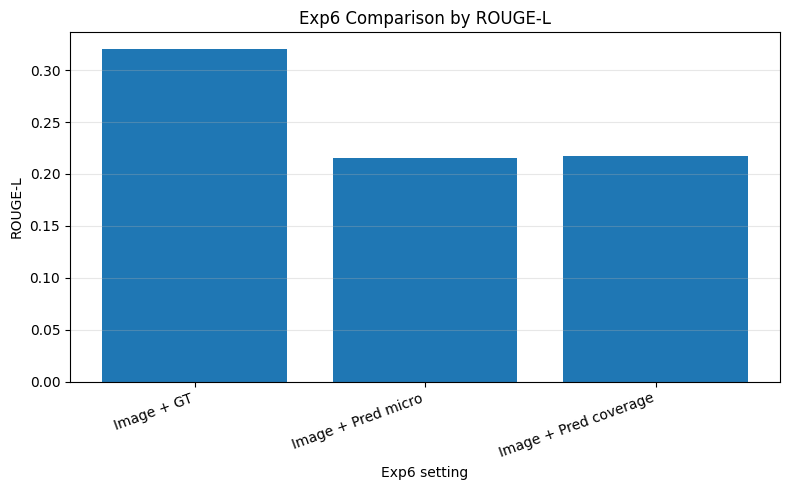

Saved: /content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5/figures/exp6_rougeL_settings_comparison.png


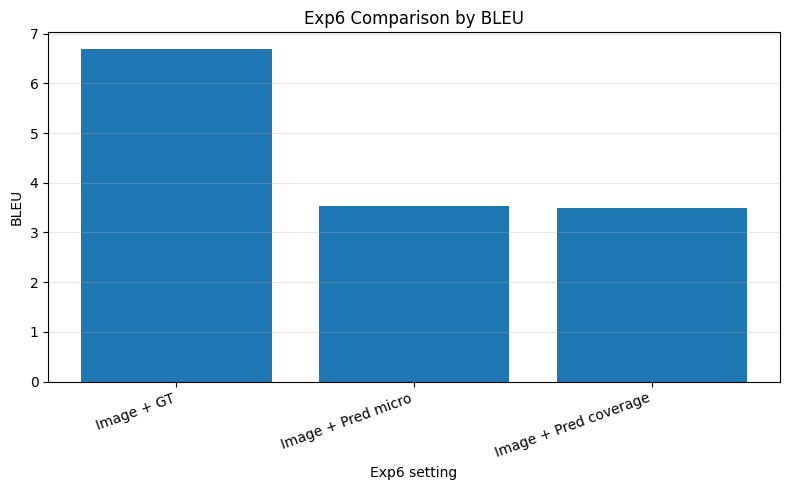

Saved: /content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5/figures/exp6_bleu_settings_comparison.png


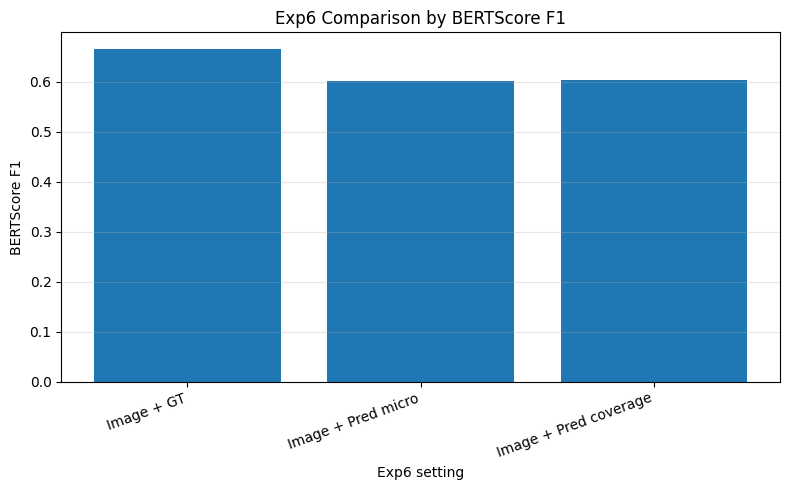

Saved: /content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5/figures/exp6_bertscore_f1_settings_comparison.png


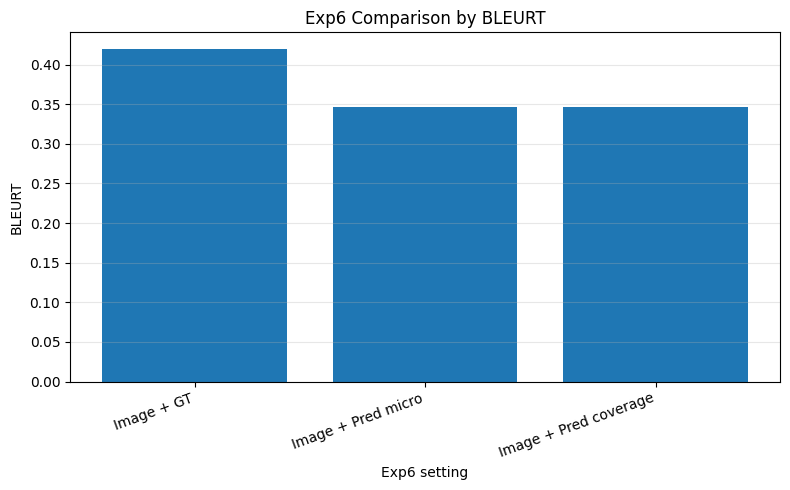

Saved: /content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5/figures/exp6_bleurt_settings_comparison.png


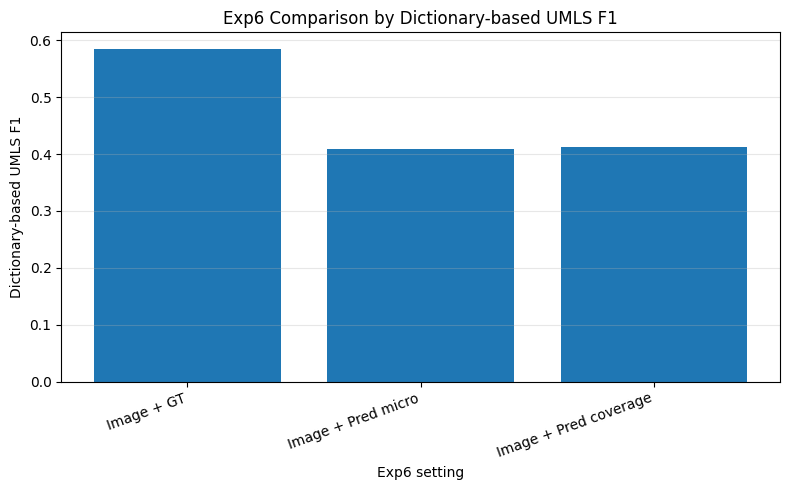

Saved: /content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5/figures/exp6_dict_umls_f1_settings_comparison.png


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

EXP6_DIR = Path("/content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5")
ADD_METRICS_DIR = EXP6_DIR / "additional_metrics"
FIG_DIR = EXP6_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

final_exp6_path = ADD_METRICS_DIR / "exp6_final_all_metrics_summary_valid3000.csv"
bert_corrected_path = ADD_METRICS_DIR / "exp6_bertscore_corrected_no_rescale_summary.csv"

exp6_df = pd.read_csv(final_exp6_path)
bert_df = pd.read_csv(bert_corrected_path)

# Replace old rescaled BERTScore with corrected no-rescale BERTScore
exp6_df = exp6_df.drop(columns=["bertscore_precision", "bertscore_recall", "bertscore_f1"], errors="ignore")
exp6_df = exp6_df.merge(bert_df, on="setting", how="left")

display(exp6_df[[
    "setting", "rougeL", "bleu", "bertscore_f1", "bleurt", "dict_umls_f1"
]])

plot_df = exp6_df.copy()
plot_df["setting_short"] = plot_df["setting"].replace({
    "Image + GT concepts": "Image + GT",
    "Image + Pred micro concepts": "Image + Pred micro",
    "Image + Pred coverage concepts": "Image + Pred coverage"
})

metrics_to_plot = ["rougeL", "bleu", "bertscore_f1", "bleurt", "dict_umls_f1"]
titles = {
    "rougeL": "ROUGE-L",
    "bleu": "BLEU",
    "bertscore_f1": "BERTScore F1",
    "bleurt": "BLEURT",
    "dict_umls_f1": "Dictionary-based UMLS F1"
}

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    plt.bar(plot_df["setting_short"], plot_df[metric])
    plt.xlabel("Exp6 setting")
    plt.ylabel(titles[metric])
    plt.title(f"Exp6 Comparison by {titles[metric]}")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    fig_path = FIG_DIR / f"exp6_{metric}_settings_comparison.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", fig_path)

,model,rougeL,bleu,bertscore_f1,bleurt,dict_umls_f1
0,Exp4 Concepts-only / GT,0.2949,5.6574,0.6405,0.3469,0.4972
1,Exp5 Image-only,0.2070,2.8757,0.6043,0.3385,0.3521
2,Exp6 Image + GT concepts,0.3205,6.6925,0.6656,0.4197,0.5850
3,Exp6 Image + Pred micro,0.2159,3.5394,0.6019,0.3463,0.4088
4,Exp6 Image + Pred coverage,0.2168,3.4938,0.6028,0.3460,0.4129


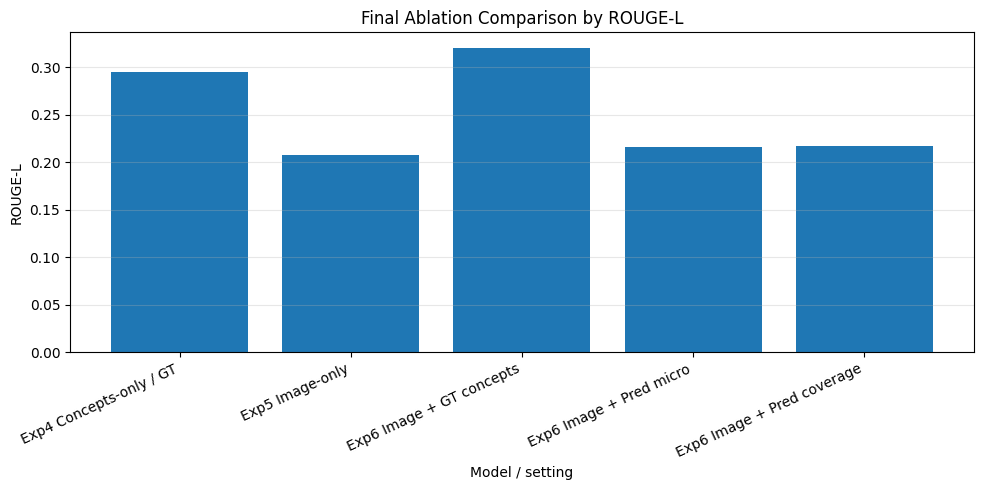

Saved: /content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5/figures/final_ablation_rougeL_comparison.png


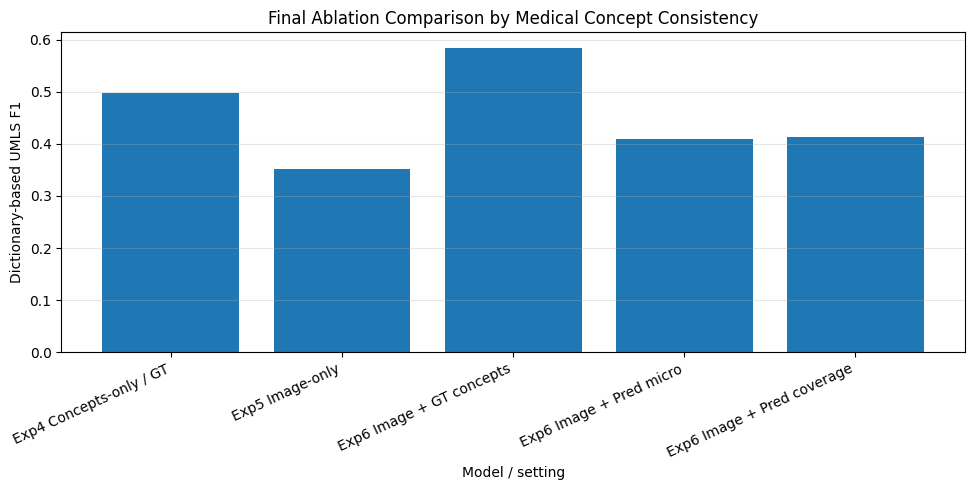

Saved: /content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5/figures/final_ablation_umls_f1_comparison.png


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

EXP6_DIR = Path("/content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5")
FIG_DIR = EXP6_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

ablation_df = pd.DataFrame([
    {
        "model": "Exp4 Concepts-only / GT",
        "rougeL": 0.2949,
        "bleu": 5.6574,
        "bertscore_f1": 0.6405,
        "bleurt": 0.3469,
        "dict_umls_f1": 0.4972
    },
    {
        "model": "Exp5 Image-only",
        "rougeL": 0.2070,
        "bleu": 2.8757,
        "bertscore_f1": 0.6043,
        "bleurt": 0.3385,
        "dict_umls_f1": 0.3521
    },
    {
        "model": "Exp6 Image + GT concepts",
        "rougeL": 0.3205,
        "bleu": 6.6925,
        "bertscore_f1": 0.6656,
        "bleurt": 0.4197,
        "dict_umls_f1": 0.5850
    },
    {
        "model": "Exp6 Image + Pred micro",
        "rougeL": 0.2159,
        "bleu": 3.5394,
        "bertscore_f1": 0.6019,
        "bleurt": 0.3463,
        "dict_umls_f1": 0.4088
    },
    {
        "model": "Exp6 Image + Pred coverage",
        "rougeL": 0.2168,
        "bleu": 3.4938,
        "bertscore_f1": 0.6028,
        "bleurt": 0.3460,
        "dict_umls_f1": 0.4129
    }
])

display(ablation_df)

# ROUGE-L comparison
plt.figure(figsize=(10, 5))
plt.bar(ablation_df["model"], ablation_df["rougeL"])
plt.xlabel("Model / setting")
plt.ylabel("ROUGE-L")
plt.title("Final Ablation Comparison by ROUGE-L")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

fig_path = FIG_DIR / "final_ablation_rougeL_comparison.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

# Dictionary UMLS F1 comparison
plt.figure(figsize=(10, 5))
plt.bar(ablation_df["model"], ablation_df["dict_umls_f1"])
plt.xlabel("Model / setting")
plt.ylabel("Dictionary-based UMLS F1")
plt.title("Final Ablation Comparison by Medical Concept Consistency")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

fig_path = FIG_DIR / "final_ablation_umls_f1_comparison.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

In [21]:
combined_metrics_path = EXP6_DIR / "figures" / "final_ablation_metrics_table.csv"
ablation_df.to_csv(combined_metrics_path, index=False)

print("Saved final ablation table:")
print(combined_metrics_path)

Saved final ablation table:
/content/drive/MyDrive/Senior2_Medical_Captioning/models/exp6_image_concept_fusion_biomedclip_visual_prefix_exp4t5/figures/final_ablation_metrics_table.csv
